# Lab Assignment 4: Support Vector Machines

In this exercise, we return to the wine quality dataset. However, this time, we will attempt to separate various pieces of cloathing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [6]:
!pip install cvxopt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


### Package Imports

In [7]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd

solvers.options['show_progress'] = False

## Accessing the Data

In [8]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

In [9]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [10]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


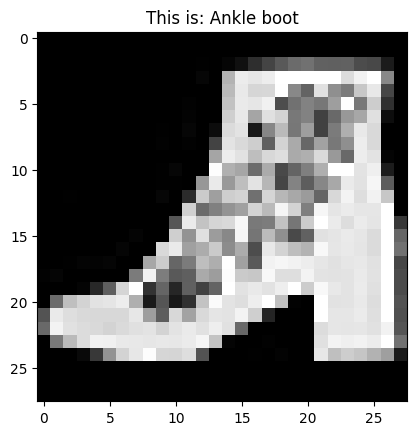

In [11]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [12]:
def nonlinear_kernel(X, Y, gamma=0.001):
  """
  Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
  Feel free to implement either 'rbf', 'poly' or 'sigmoid'
  WARNING: 'rbf' can be quite slow and there exist some approximation methods
  Parameters
  ----------
  X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

  y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
  """
  X_sq = np.sum(X**2, axis=1, keepdims=True)
  Y_sq = np.sum(Y**2, axis=1, keepdims=True)
  sq_dists = X_sq + Y_sq.T - 2 * X @ Y.T
  return np.exp(-gamma * sq_dists)


In [13]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0, gamma=0.001):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = C
    self.gamma = gamma


  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization 
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.
    
    n_samples , n_features = X.shape
    
    y_class = y
    
    K = self.kernel(X, X, gamma=self.gamma)
    
    self.b = 0
    
    P = matrix(np.outer(y_class, y_class) * K)
    q = matrix(-np.ones(n_samples))
    
    G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
    h = matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C)))
    
    A = matrix(y_class.astype(float), (1, n_samples))
    b = matrix(0.0)

    
    solution = solvers.qp(P, q, G, h, A, b)
    alphas = np.ravel(solution['x'])
    
    sv = alphas > 1e-5

    self.alphas = alphas[sv]
    self.support_vectors = X[sv]
    self.support_labels = y_class[sv]
    
    self.b = np.mean(
    self.support_labels - np.dot(K[np.ix_(sv, sv)], self.alphas * self.support_labels)
)   
    return self
  
  def decision_function(self, X):
    """
    Compute raw SVM decision values (before sign)
    """
    K = self.kernel(X, self.support_vectors, gamma=self.gamma)
    return np.dot(K, self.alphas * self.support_labels) + self.b

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """
    decision = self.decision_function(X)
    return np.where(decision >= 0, 1, -1)

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """
    
    y_pred = self.predict(X)
    y_true = np.where(y <= 0, -1, 1)
    accuracy = np.mean(y_pred == y_true)

    return accuracy


## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [14]:
# subsample to 100 per class max
from collections import defaultdict

idx_by_class = defaultdict(list)
for i, label in enumerate(train_samples_labels):
    idx_by_class[label].append(i)

keep = []
for label, idxs in idx_by_class.items():
    keep.extend(idxs[:100])

train_small = train_samples.to_numpy()[keep]
labels_small = train_samples_labels.iloc[keep].to_numpy()

In [15]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
classes = np.unique(labels_small)

# One-vs-Rest
ovr_classifiers = []
for c in classes:
    y_binary = np.where(labels_small == c, 1, -1)
    svm = SVM(C=1)
    svm.fit(train_small, y_binary)
    ovr_classifiers.append(svm)

ovr_scores = np.column_stack([
    svm.decision_function(test_samples.to_numpy()) for svm in ovr_classifiers
])
pred_ovr = classes[np.argmax(ovr_scores, axis=1)]
acc_ovr = np.mean(pred_ovr == test_samples_labels)
print("One-vs-Rest Accuracy:", acc_ovr)


One-vs-Rest Accuracy: 0.085


In [16]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
from itertools import combinations

ovo_classifiers = {}
for c1, c2 in combinations(classes, 2):
    mask = (train_samples_labels == c1) | (train_samples_labels == c2)
    X_pair = train_samples.to_numpy()[mask]
    y_pair = np.where(train_samples_labels[mask] == c1, 1, -1)
    svm = SVM(C=1)
    svm.fit(X_pair, y_pair)
    ovo_classifiers[(c1, c2)] = svm

class_idx = {c: i for i, c in enumerate(classes)}
votes = np.zeros((test_samples.shape[0], len(classes)))
for (c1, c2), svm in ovo_classifiers.items():
    preds = svm.predict(test_samples.to_numpy())
    votes[preds == 1, class_idx[c1]] += 1
    votes[preds == -1, class_idx[c2]] += 1

pred_ovo = classes[np.argmax(votes, axis=1)]
acc_ovo = np.mean(pred_ovo == test_samples_labels)
print("One-vs-One Accuracy:", acc_ovo)

One-vs-One Accuracy: 0.09


## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [20]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
from itertools import combinations

test_np = test_samples.to_numpy() / 255.0
train_small = train_small / 255.0

C_values = np.logspace(-1, 3, 5) #0.1, 1, 10, 109 ...
gamma_values = np.logspace(-4, -1, 4) 

results = []

for C in C_values:
    for gamma in gamma_values:
        ovr = []
        for c in classes:
            y_binary = np.where(labels_small == c, 1, -1)
            svm = SVM(C=C, gamma=gamma)
            svm.fit(train_small, y_binary)
            ovr.append(svm)
        scores = np.column_stack([s.decision_function(test_np) for s in ovr])
        preds = classes[np.argmax(scores, axis=1)]
        acc = np.mean(preds == test_samples_labels.to_numpy())
        results.append((C, gamma, acc))
        print(f"C={C:.1f}, gamma={gamma:.4f}, acc={acc:.4f}")

best = max(results, key=lambda x: x[2])
print(f"\nBest: C={best[0]}, gamma={best[1]}, acc={best[2]:.4f}")

C=0.1, gamma=0.0001, acc=0.3950
C=0.1, gamma=0.0010, acc=0.6750
C=0.1, gamma=0.0100, acc=0.7600
C=0.1, gamma=0.1000, acc=0.7350
C=1.0, gamma=0.0001, acc=0.5800
C=1.0, gamma=0.0010, acc=0.7650
C=1.0, gamma=0.0100, acc=0.8300
C=1.0, gamma=0.1000, acc=0.7300
C=10.0, gamma=0.0001, acc=0.7750
C=10.0, gamma=0.0010, acc=0.8400
C=10.0, gamma=0.0100, acc=0.8400
C=10.0, gamma=0.1000, acc=0.7400
C=100.0, gamma=0.0001, acc=0.8350
C=100.0, gamma=0.0010, acc=0.8350
C=100.0, gamma=0.0100, acc=0.8250
C=100.0, gamma=0.1000, acc=0.7400
C=1000.0, gamma=0.0001, acc=0.8200
C=1000.0, gamma=0.0010, acc=0.8050
C=1000.0, gamma=0.0100, acc=0.8250
C=1000.0, gamma=0.1000, acc=0.7400

Best: C=10.0, gamma=0.001, acc=0.8400


## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

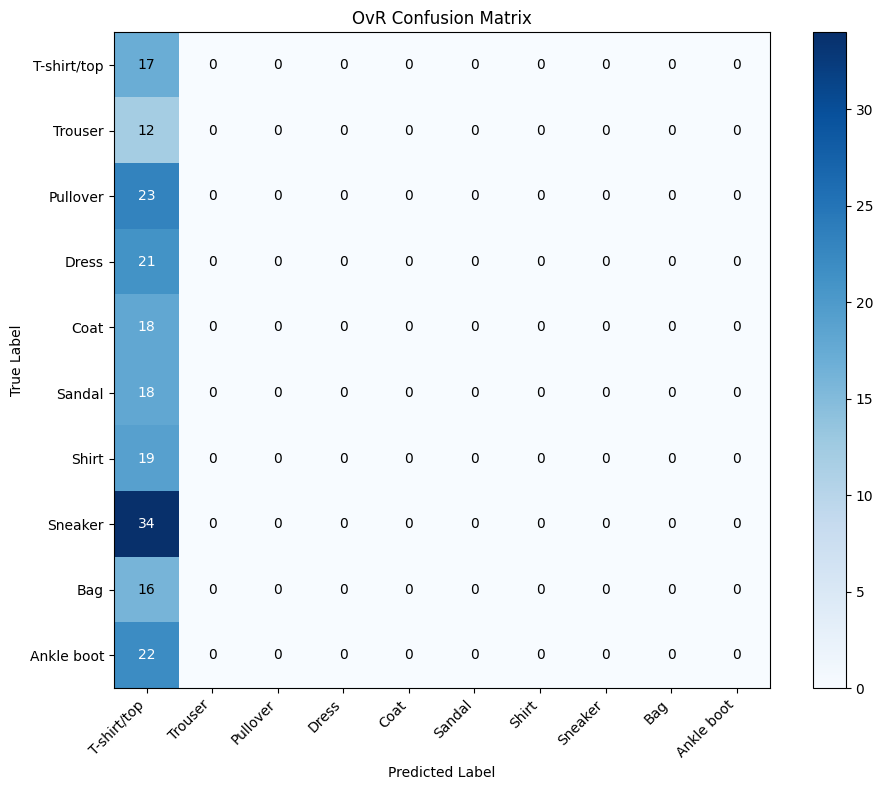

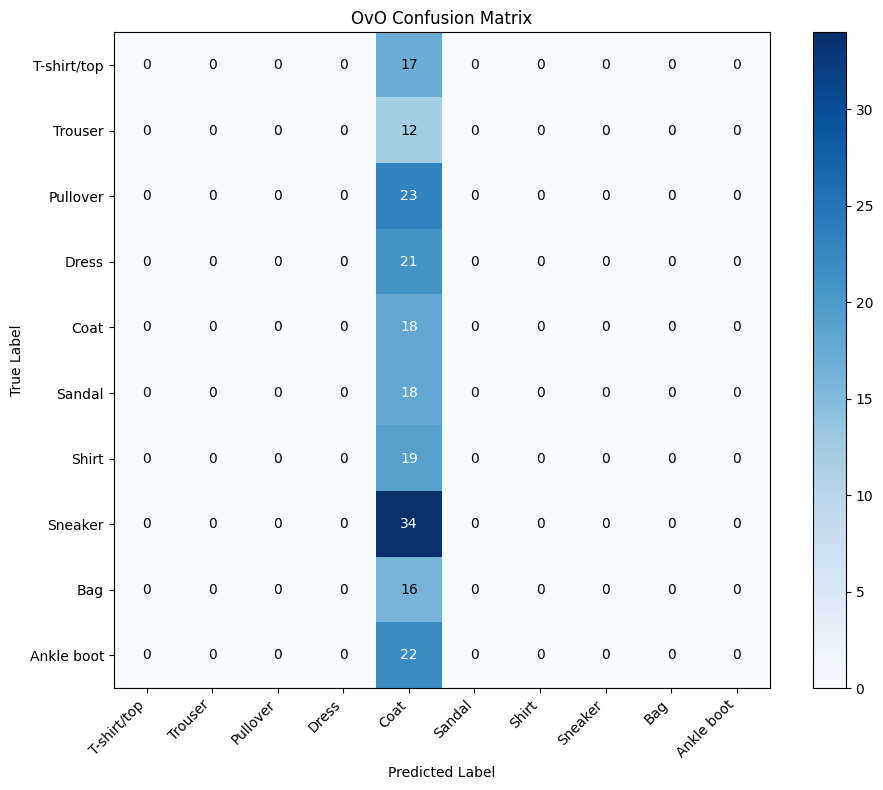

In [ ]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
from itertools import combinations

def confusion_matrix(y_true, y_pred, classes):
    n = len(classes)
    cm = np.zeros((n, n), dtype=int)
    class_idx = {c: i for i, c in enumerate(classes)}
    for t, p in zip(y_true, y_pred):
        cm[class_idx[t], class_idx[p]] += 1
    return cm

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im)
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_yticklabels(classes)
    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > thresh else 'black')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

label_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

cm_ovr = confusion_matrix(test_samples_labels.to_numpy(), pred_ovr, classes)
plot_confusion_matrix(cm_ovr, label_names, title='OvR Confusion Matrix')

cm_ovo = confusion_matrix(test_samples_labels.to_numpy(), pred_ovo, classes)
plot_confusion_matrix(cm_ovo, label_names, title='OvO Confusion Matrix')


### What to Submit
Please submit the following:

1. A Jupyter noteboon that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.